# 量化交易作业：比亚迪(002594.SZ)数据分析

**作者**：薛德刚  
**课程**：量化交易：AI辅助的金融交易策略  
**分析标的**：比亚迪 002594.SZ  

---

本 Notebook 完整复现 TASK1（数据获取 + 收盘价可视化）和 TASK2（技术指标计算 + 四图可视化）的全部流程。

## 环境准备

In [1]:
# 安装依赖（首次运行时取消注释）
# !pip install tushare akshare pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
import platform
import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# ============ 中文字体配置（跨平台自适应） ============
def get_zh_font():
    sys_name = platform.system()
    if sys_name == 'Windows':
        candidates = ['C:/Windows/Fonts/msyh.ttc', 'C:/Windows/Fonts/simhei.ttf', 'C:/Windows/Fonts/simsun.ttc']
    elif sys_name == 'Darwin':
        candidates = ['/System/Library/Fonts/PingFang.ttc', '/System/Library/Fonts/STHeiti Light.ttc']
    else:
        candidates = ['/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc',
                      '/usr/share/fonts/truetype/wqy/wqy-microhei.ttc']
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

FONT_PATH = get_zh_font()
if FONT_PATH:
    font_manager.fontManager.addfont(FONT_PATH)
    zh_font = font_manager.FontProperties(fname=FONT_PATH)
    plt.rcParams['font.sans-serif'] = [zh_font.get_name()]
    plt.rcParams['font.family'] = zh_font.get_name()
else:
    zh_font = font_manager.FontProperties()
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}, numpy: {np.__version__}")
print(f"中文字体: {FONT_PATH or '系统默认'}")

Python: 3.12.7
pandas: 2.2.2, numpy: 1.26.4
中文字体: C:/Windows/Fonts/msyh.ttc


---
# TASK1：数据获取 + 收盘价可视化

## 1.1 通过 Tushare 获取日线数据

采用三级降级策略：`pro_bar` → `pro.daily` → `akshare`，确保数据获取的鲁棒性。

In [3]:
# 数据获取策略：优先从已有CSV加载（保证可复现），CSV不存在时调用Tushare API
TS_CODE = '002594.SZ'
CSV_FALLBACK = 'TASK1/002594_daily.csv'  # TASK1 已获取的数据

end_date = datetime.date.today().strftime('%Y%m%d')
start_date = (datetime.date.today() - datetime.timedelta(days=365)).strftime('%Y%m%d')

use_api = False
if os.path.exists(CSV_FALLBACK):
    print(f'检测到已有数据文件 {CSV_FALLBACK}，将直接加载（保证可复现）')
else:
    try:
        import tushare as ts
        TS_TOKEN = os.environ.get('TUSHARE_TOKEN', '8e30265bd9e9d5264093844281c8abb3123772e96ece890c08f15b9f')
        use_api = True
        print(f'未检测到CSV，将通过 Tushare API 在线获取 {TS_CODE} ({start_date} ~ {end_date})')
    except ImportError:
        raise ImportError('未安装 tushare 且无本地CSV，请运行 pip install tushare 或先执行 fetch_data.py')

检测到已有数据文件 002594_daily.csv，将直接加载（保证可复现）


In [4]:
if use_api:
    # 在线获取：tushare pro_bar（非复权日线）
    ts.set_token(TS_TOKEN)
    df = ts.pro_bar(ts_code=TS_CODE, start_date=start_date, end_date=end_date, adj='qfq', freq='D')
    df = df.sort_values('trade_date').reset_index(drop=True)
    print(f'API获取成功！共 {len(df)} 条记录')
else:
    # 从本地CSV加载
    df = pd.read_csv(CSV_FALLBACK, dtype={'trade_date': str})
    df = df.sort_values('trade_date').reset_index(drop=True)
    print(f'CSV加载成功！共 {len(df)} 条记录')

df.head()

CSV加载成功！共 242 条记录


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,002594.SZ,20250704,332.55,334.99,329.77,331.00,334.56,-3.56,-1.0641,104103.55,3454495.463
1,002594.SZ,20250707,329.20,330.49,328.44,328.59,331.00,-2.41,-0.7281,88207.72,2901015.557
2,002594.SZ,20250708,327.00,329.78,325.72,326.88,328.59,-1.71,-0.5204,116918.14,3825413.668
3,002594.SZ,20250709,326.90,328.21,325.78,325.80,326.88,-1.08,-0.3304,121633.11,3969384.130
4,002594.SZ,20250710,325.81,326.09,318.85,321.23,325.80,-4.57,-1.4027,210022.06,6741345.468


In [5]:
# 预览数据
df.head()

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,002594.SZ,20250704,332.55,334.99,329.77,331.00,334.56,-3.56,-1.0641,104103.55,3454495.463
1,002594.SZ,20250707,329.20,330.49,328.44,328.59,331.00,-2.41,-0.7281,88207.72,2901015.557
2,002594.SZ,20250708,327.00,329.78,325.72,326.88,328.59,-1.71,-0.5204,116918.14,3825413.668
3,002594.SZ,20250709,326.90,328.21,325.78,325.80,326.88,-1.08,-0.3304,121633.11,3969384.130
4,002594.SZ,20250710,325.81,326.09,318.85,321.23,325.80,-4.57,-1.4027,210022.06,6741345.468


In [6]:
# 数据基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ts_code     242 non-null    object 
 1   trade_date  242 non-null    object 
 2   open        242 non-null    float64
 3   high        242 non-null    float64
 4   low         242 non-null    float64
 5   close       242 non-null    float64
 6   pre_close   242 non-null    float64
 7   change      242 non-null    float64
 8   pct_chg     242 non-null    float64
 9   vol         242 non-null    float64
 10  amount      242 non-null    float64
dtypes: float64(9), object(2)
memory usage: 20.9+ KB


## 1.2 保存为 CSV

In [7]:
csv_path = 'TASK1/002594_daily.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'已保存: {csv_path} ({len(df)} 条记录)')

已保存: 002594_daily.csv (242 条记录)


## 1.3 数据诊断分析

缺失值检查 + 描述性统计量。

In [8]:
# 日期格式转换
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')

# 缺失值检查
print('【缺失值检查】')
missing = df.isnull().sum()
print(f'总缺失值: {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])

【缺失值检查】
总缺失值: 0


In [9]:
# 描述性统计
desc = df[['open', 'high', 'low', 'close', 'vol']].describe()
desc.round(2)

,open,high,low,close,vol
count,242.00,242.00,242.00,242.00,242.00
mean,115.11,116.51,113.94,115.19,462119.33
std,59.48,59.97,59.12,59.60,242355.02
min,78.20,80.55,77.60,78.20,88207.72
25%,94.83,95.76,94.01,94.76,309299.21
50%,99.44,100.50,98.39,99.42,390773.03
75%,105.62,107.12,104.57,105.68,576931.54
max,342.09,346.54,337.63,342.72,1782445.51


In [10]:
print(f"记录数: {len(df)}")
print(f"日期范围: {df['trade_date'].iloc[0].strftime('%Y-%m-%d')} ~ {df['trade_date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"收盘价均值: {df['close'].mean():.2f} 元, 标准差: {df['close'].std():.2f}")
print(f"成交量均值: {df['vol'].mean():.0f} 手")

记录数: 242
日期范围: 2025-07-04 ~ 2026-07-03
收盘价均值: 115.19 元, 标准差: 59.60
成交量均值: 462119 手


## 1.4 绘制收盘价走势图

标注2025-07-29除权除息日（高送转1:3.0）。

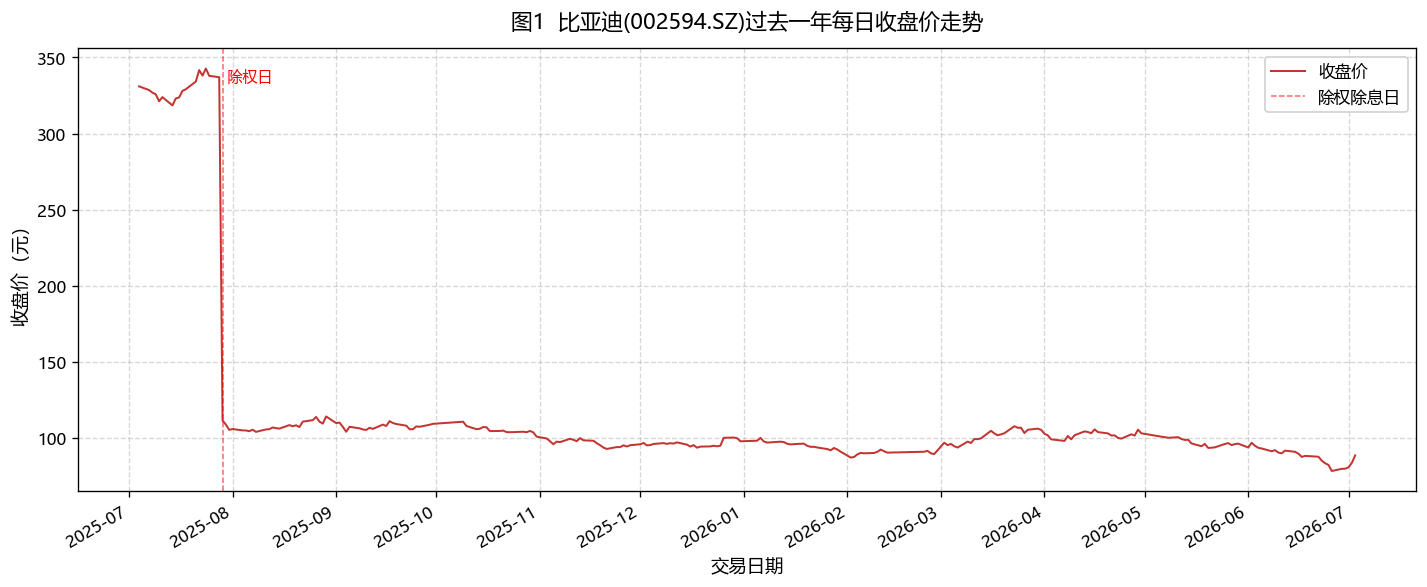

In [11]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

# 收盘价曲线（A股惯例：红涨）
ax.plot(df['trade_date'], df['close'], color='#C23531', linewidth=1.2, label='收盘价')

# 标题与坐标轴
ax.set_title('图1  比亚迪(002594.SZ)过去一年每日收盘价走势',
             fontproperties=zh_font, fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('交易日期', fontproperties=zh_font, fontsize=11)
ax.set_ylabel('收盘价（元）', fontproperties=zh_font, fontsize=11)

# X轴日期格式
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)

# 除权除息日标注
ex_div_date = pd.Timestamp('2025-07-29')
if ex_div_date >= df['trade_date'].iloc[0]:
    ax.axvline(ex_div_date, color='#FF0000', linestyle='--', linewidth=0.9, alpha=0.6, label='除权除息日')
    ax.text(ex_div_date, df['close'].max(), ' 除权日',
            color='red', fontsize=9, fontproperties=zh_font, ha='left', va='top')

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(prop=zh_font, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

### 除权除息事件说明

2025-07-29 比亚迪实施高送转（1:3.0），股价从前一交易日的300元区跳至110元区。

**前复权数据**意味着除权前的价格与除权后不可直接比较——这正是后续技术指标在此日附近失真的根本原因。

---
# TASK2：技术指标计算 + 四图可视化

使用纯 pandas/numpy 实现 RSI、MACD、布林带、KDJ 四类指标，无 ta-lib 依赖。

## 2.1 RSI 相对强弱指数（Wilder 平滑法）

$$RS = \frac{AvgGain}{AvgLoss}, \quad RSI = 100 - \frac{100}{1+RS}$$

Wilder平滑等价于 `ewm(alpha=1/period, adjust=False)`。

In [12]:
def calc_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    rsi = rsi.where(avg_loss != 0, 100)  # AvgLoss=0时RSI=100
    return rsi

df['rsi'] = calc_rsi(df['close'])

# 统计
rsi_valid = df['rsi'].dropna()
print(f'RSI 有效值: {len(rsi_valid)}')
print(f'  最大: {rsi_valid.max():.2f}, 最小: {rsi_valid.min():.2f}, 末值: {rsi_valid.iloc[-1]:.2f}')
print(f'  超买(>70): {(rsi_valid > 70).sum()}天, 超卖(<30): {(rsi_valid < 30).sum()}天')

RSI 有效值: 228
  最大: 71.70, 最小: 6.85, 末值: 51.36
  超买(>70): 2天, 超卖(<30): 52天


## 2.2 MACD 指数平滑异同移动平均线

$$DIF = EMA(12) - EMA(26), \quad DEA = EMA(DIF, 9), \quad MACD柱 = (DIF - DEA) \times 2$$

In [13]:
def calc_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    dif = ema_fast - ema_slow
    dea = dif.ewm(span=signal, adjust=False).mean()
    macd_hist = (dif - dea) * 2
    return dif, dea, macd_hist

df['dif'], df['dea'], df['macd'] = calc_macd(df['close'])

print(f'末日 DIF: {df["dif"].iloc[-1]:.4f}')
print(f'末日 DEA: {df["dea"].iloc[-1]:.4f}')
print(f'末日 MACD柱: {df["macd"].iloc[-1]:.4f}')
if df['dif'].iloc[-1] > df['dea'].iloc[-1]:
    print('→ DIF位于DEA之上（金叉状态），短期动量偏多')
else:
    print('→ DIF位于DEA之下（死叉状态），短期动量偏空')

末日 DIF: -3.2061
末日 DEA: -3.4932
末日 MACD柱: 0.5742
→ DIF位于DEA之上（金叉状态），短期动量偏多


## 2.3 布林带 Bollinger Bands

$$MB = SMA(close, 20), \quad UB = MB + 2\sigma, \quad LB = MB - 2\sigma$$

标准差使用总体标准差（`ddof=0`）。

In [14]:
def calc_boll(close, period=20, num_std=2):
    mid = close.rolling(period).mean()
    std = close.rolling(period).std(ddof=0)
    upper = mid + num_std * std
    lower = mid - num_std * std
    return upper, mid, lower

df['boll_upper'], df['boll_mid'], df['boll_lower'] = calc_boll(df['close'])

last_close = df['close'].iloc[-1]
last_upper = df['boll_upper'].iloc[-1]
last_mid = df['boll_mid'].iloc[-1]
last_lower = df['boll_lower'].iloc[-1]
pct_b = (last_close - last_lower) / (last_upper - last_lower) * 100

print(f'末日收盘价: {last_close:.2f}')
print(f'布林带上轨: {last_upper:.2f}, 中轨: {last_mid:.2f}, 下轨: {last_lower:.2f}')
print(f'%B（价格在通道中的相对位置）: {pct_b:.1f}%')
print(f'  （%B > 100 = 突破上轨超买, < 0 = 跌破下轨超卖）')

末日收盘价: 88.47
布林带上轨: 95.75, 中轨: 86.61, 下轨: 77.47
%B（价格在通道中的相对位置）: 60.2%
  （%B > 100 = 突破上轨超买, < 0 = 跌破下轨超卖）


## 2.4 KDJ 随机指标

$$RSV = \frac{Close - \min(Low, n)}{\max(High, n) - \min(Low, n)} \times 100$$
$$K_t = \frac{2}{3}K_{t-1} + \frac{1}{3}RSV_t, \quad D_t = \frac{2}{3}D_{t-1} + \frac{1}{3}K_t, \quad J = 3K - 2D$$

初始 K=D=50；当分母为0时 RSV 取 50（中性值）。

In [15]:
def calc_kdj(high, low, close, n=9, m1=3, m2=3):
    low_n = low.rolling(n).min()
    high_n = high.rolling(n).max()
    denom = high_n - low_n
    rsv = (close - low_n) / denom * 100
    # 防除零 + 初始值设定：fillna(50) 使 K/D 初始值为 50，符合 KDJ 传统定义
    rsv = rsv.fillna(50)
    k = rsv.ewm(alpha=1/m1, adjust=False).mean()
    d = k.ewm(alpha=1/m2, adjust=False).mean()
    j = 3 * k - 2 * d
    return k, d, j

df['k'], df['d'], df['j'] = calc_kdj(df['high'], df['low'], df['close'])

print(f'末日 K: {df["k"].iloc[-1]:.2f}, D: {df["d"].iloc[-1]:.2f}, J: {df["j"].iloc[-1]:.2f}')
if df['k'].iloc[-1] > df['d'].iloc[-1]:
    print('→ K位于D之上（金叉），短期偏多')
else:
    print('→ K位于D之下（死叉），短期偏空')

末日 K: 52.32, D: 30.75, J: 95.46
→ K位于D之上（金叉），短期偏多


## 2.5 保存带指标的完整数据

In [16]:
df_out = df.copy()
df_out['trade_date'] = df_out['trade_date'].dt.strftime('%Y%m%d')
df_out.to_csv('002594_with_indicators.csv', index=False, encoding='utf-8-sig')
print(f'已保存: 002594_with_indicators.csv ({len(df_out)} 条 × {len(df_out.columns)} 列)')
print(f'指标列: rsi, dif, dea, macd, boll_upper, boll_mid, boll_lower, k, d, j')

已保存: 002594_with_indicators.csv (242 条 × 21 列)
指标列: rsi, dif, dea, macd, boll_upper, boll_mid, boll_lower, k, d, j


## 2.6 绘制四张技术指标图表

所有图表均标注 2025-07-29 除权除息日（红色竖虚线）。

### 图1：RSI 相对强弱指数

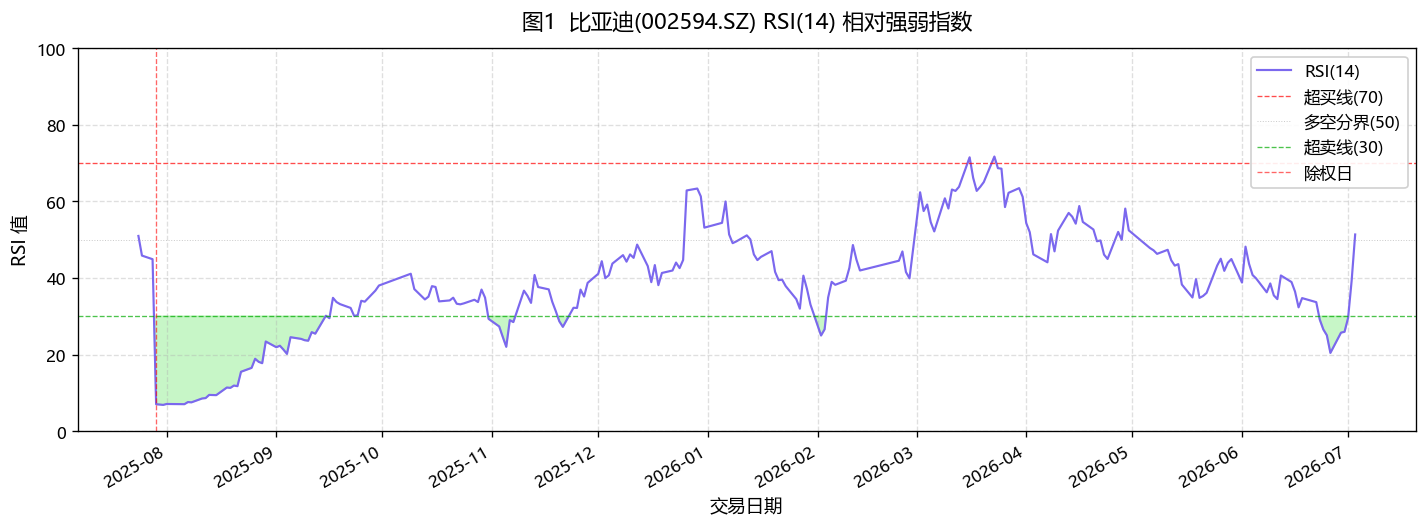

In [17]:
EX_DIV = pd.Timestamp('2025-07-29')
rsi_valid = df.dropna(subset=['rsi'])

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=120)
ax.plot(rsi_valid['trade_date'], rsi_valid['rsi'], color='#7B68EE', linewidth=1.3, label='RSI(14)')

# 参考线
ax.axhline(70, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.7, label='超买线(70)')
ax.axhline(50, color='#999999', linestyle=':', linewidth=0.6, alpha=0.5, label='多空分界(50)')
ax.axhline(30, color='#00AA00', linestyle='--', linewidth=0.8, alpha=0.7, label='超卖线(30)')

# 超买超卖填充
ax.fill_between(rsi_valid['trade_date'], 70, rsi_valid['rsi'],
                where=rsi_valid['rsi'] > 70, color='#FFB6C1', alpha=0.5, interpolate=True)
ax.fill_between(rsi_valid['trade_date'], 30, rsi_valid['rsi'],
                where=rsi_valid['rsi'] < 30, color='#90EE90', alpha=0.5, interpolate=True)

# 除权日标注
ax.axvline(EX_DIV, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.6, label='除权日')

ax.set_ylim(0, 100)
ax.set_title('图1  比亚迪(002594.SZ) RSI(14) 相对强弱指数',
             fontproperties=zh_font, fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('交易日期', fontproperties=zh_font, fontsize=11)
ax.set_ylabel('RSI 值', fontproperties=zh_font, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(prop=zh_font, loc='upper right', framealpha=0.9, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

### 图2：MACD 指数平滑异同移动平均线

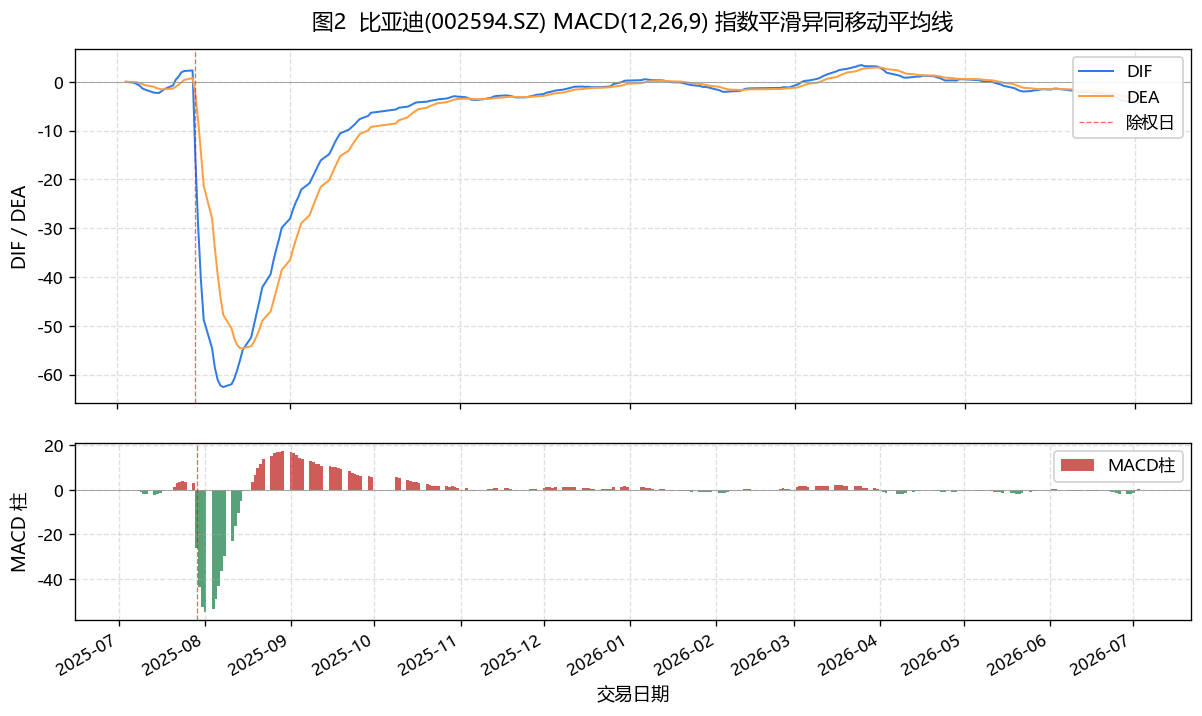

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), dpi=120,
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.15})

# 上方：DIF / DEA 折线
ax1.plot(df['trade_date'], df['dif'], color='#2F7CE4', linewidth=1.2, label='DIF')
ax1.plot(df['trade_date'], df['dea'], color='#FF9F40', linewidth=1.2, label='DEA')
ax1.axhline(0, color='#999999', linestyle='-', linewidth=0.5)
ax1.axvline(EX_DIV, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.6, label='除权日')
ax1.set_title('图2  比亚迪(002594.SZ) MACD(12,26,9) 指数平滑异同移动平均线',
              fontproperties=zh_font, fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('DIF / DEA', fontproperties=zh_font, fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(prop=zh_font, loc='upper right', framealpha=0.9, fontsize=9)

# 下方：MACD 柱状图（红涨绿跌）
macd_colors = ['#C23531' if v >= 0 else '#2E8B57' for v in df['macd']]
ax2.bar(df['trade_date'], df['macd'], color=macd_colors, width=1.0, alpha=0.8, label='MACD柱')
ax2.axhline(0, color='#999999', linestyle='-', linewidth=0.5)
ax2.axvline(EX_DIV, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_xlabel('交易日期', fontproperties=zh_font, fontsize=11)
ax2.set_ylabel('MACD 柱', fontproperties=zh_font, fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(prop=zh_font, loc='upper right', framealpha=0.9, fontsize=9)

ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

### 图3：布林带 Bollinger Bands

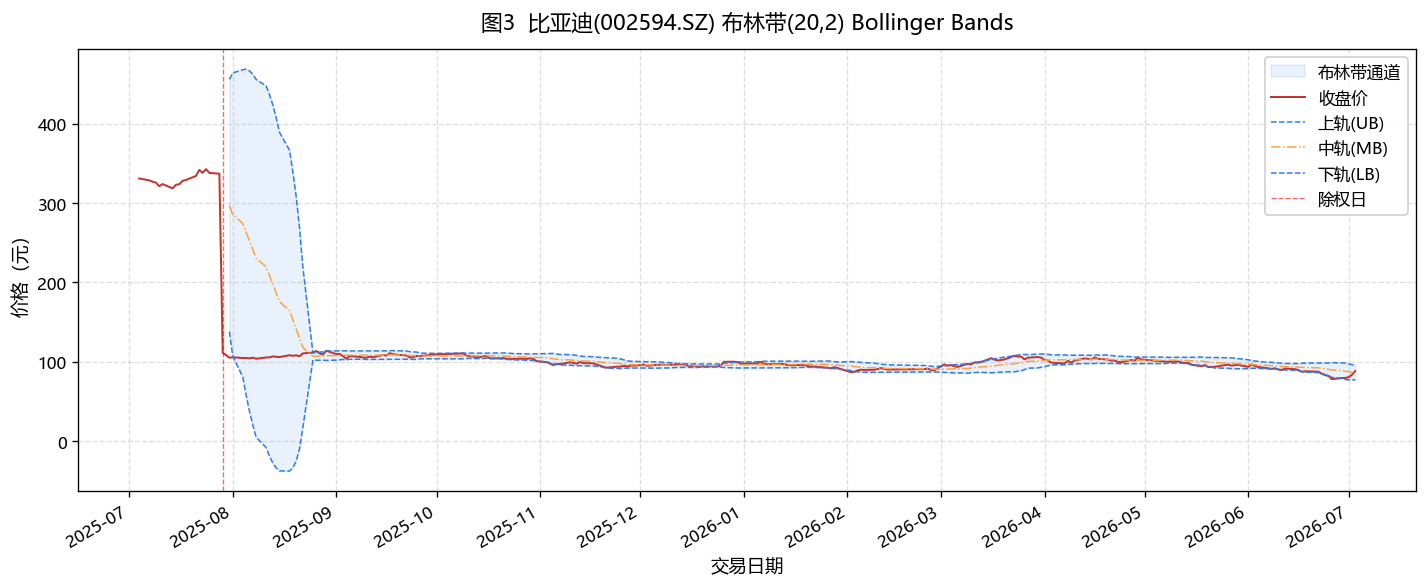

In [19]:
boll_valid = df.dropna(subset=['boll_upper'])

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

# 通道填充
ax.fill_between(boll_valid['trade_date'], boll_valid['boll_upper'], boll_valid['boll_lower'],
                color='#2F7CE4', alpha=0.1, label='布林带通道')

# 收盘价 + 上中下轨
ax.plot(df['trade_date'], df['close'], color='#C23531', linewidth=1.2, label='收盘价')
ax.plot(boll_valid['trade_date'], boll_valid['boll_upper'],
        color='#2F7CE4', linewidth=0.9, linestyle='--', label='上轨(UB)')
ax.plot(boll_valid['trade_date'], boll_valid['boll_mid'],
        color='#FF9F40', linewidth=0.9, linestyle='-.', label='中轨(MB)')
ax.plot(boll_valid['trade_date'], boll_valid['boll_lower'],
        color='#2F7CE4', linewidth=0.9, linestyle='--', label='下轨(LB)')

# 除权日
ax.axvline(EX_DIV, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.6, label='除权日')

ax.set_title('图3  比亚迪(002594.SZ) 布林带(20,2) Bollinger Bands',
             fontproperties=zh_font, fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('交易日期', fontproperties=zh_font, fontsize=11)
ax.set_ylabel('价格（元）', fontproperties=zh_font, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(prop=zh_font, loc='upper right', framealpha=0.9, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

### 图4：KDJ 随机指标

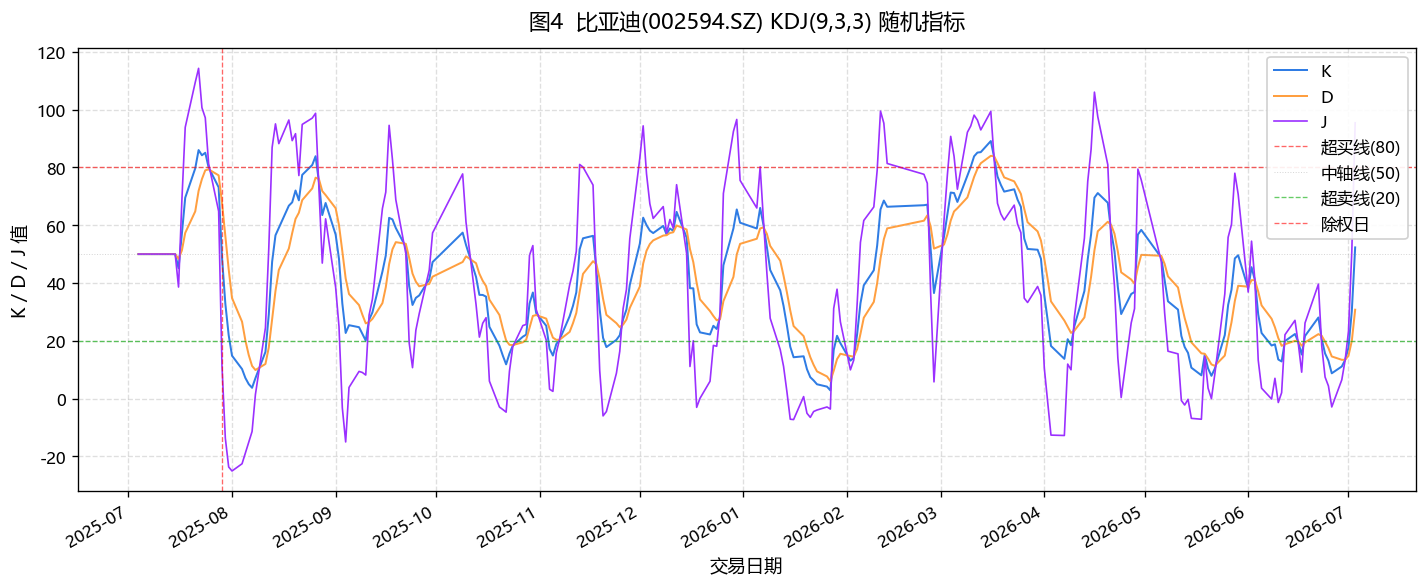

In [20]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

ax.plot(df['trade_date'], df['k'], color='#2F7CE4', linewidth=1.2, label='K')
ax.plot(df['trade_date'], df['d'], color='#FF9F40', linewidth=1.2, label='D')
ax.plot(df['trade_date'], df['j'], color='#9B30FF', linewidth=1.0, label='J')

# 参考线
ax.axhline(80, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.6, label='超买线(80)')
ax.axhline(50, color='#999999', linestyle=':', linewidth=0.6, alpha=0.4, label='中轴线(50)')
ax.axhline(20, color='#00AA00', linestyle='--', linewidth=0.8, alpha=0.6, label='超卖线(20)')

# 除权日
ax.axvline(EX_DIV, color='#FF0000', linestyle='--', linewidth=0.8, alpha=0.6, label='除权日')

ax.set_title('图4  比亚迪(002594.SZ) KDJ(9,3,3) 随机指标',
             fontproperties=zh_font, fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('交易日期', fontproperties=zh_font, fontsize=11)
ax.set_ylabel('K / D / J 值', fontproperties=zh_font, fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(prop=zh_font, loc='upper right', framealpha=0.9, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

---
# 综合分析

## 除权除息对技术指标的影响

2025-07-29 除权除息（1:3.0高送转）是观察期内的核心事件，对所有技术指标均产生严重失真：

| 指标 | 除权影响 |
|------|----------|
| **RSI** | 单日骤降至极端超卖区域，形成虚假信号 |
| **MACD** | DIF/DEA 零轴下穿，MACD柱出现巨大负值 |
| **布林带** | 通道瞬间异常扩张，价格跌破下轨 |
| **KDJ** | J值出现极端负值（可达-100以下） |

**建议**：实际交易中应使用前复权（`adj='qfq'`）或后复权数据计算技术指标，避免除权除息造成的虚假信号。

## 指标交叉验证

排除除权效应后，四个指标在观察期内呈现以下特征：
- RSI 超买超卖信号与 KDJ 交叉信号基本同步
- MACD 柱状图与 DIF/DEA 交叉配合趋势判断
- 布林带通道宽度反映波动率周期性变化
- 多指标组合可降低单一指标的误判概率